# Detección de Virus Troyanos con Redes Neuronales Convolucionales Sobre Grafos (GCN)

## Introducción 

Los **virus troyanos** son una de las amenazas más comunes y peligrosas en ciberseguridad. Se caracterizan por disfrazarse como software legítimo para engañar al usuario y ejecutar acciones maliciosas, como robo de información, control remoto o instalación de otros tipos de malware.

Tradicionalmente, la detección de troyanos se ha basado en firmas o reglas específicas. Sin embargo, este enfoque es **limitado frente a variantes nuevas o mutaciones** del malware, ya que no generaliza bien ante ataques desconocidos.

### Solución basada en Machine Learning

El aprendizaje automático ofrece una alternativa poderosa: entrenar modelos capaces de **identificar patrones anómalos** en los datos, incluso si el virus es desconocido. Pero la mayoría de estos modelos trabajan con datos tabulares o secuencias, lo cual puede ser insuficiente para capturar **relaciones estructurales** más complejas.

### Redes Convolucionales sobre Grafos (GCN)

Las **Graph Convolutional Networks (GCNs)** permiten modelar relaciones entre instancias como un grafo, donde:
- Cada **nodo** representa una muestra (por ejemplo, un paquete de red).
- Cada **arista** representa una relación de similitud (por ejemplo, cercanía en características).

Este enfoque permite capturar **información contextual** entre muestras, mejorando la capacidad del modelo para detectar troyanos sutiles o camuflados.

![Graph Convolutional Networks](https://snap.stanford.edu/decagon/decagon-overview.png)

### Objetivo de este notebook

Este trabajo busca **replicar y explicar el paper** “Trojan Virus Detection and Classification Based on Graph Convolutional Neural Network Algorithm”, proponiendo:
- La carga y preparación del dataset.
- La construcción del grafo de relaciones entre instancias.
- La implementación y entrenamiento de un modelo GCN.
- La evaluación del modelo con una métrica estándar: accuracy.

El objetivo final es demostrar cómo las GCN pueden mejorar significativamente la detección de malware en entornos modernos y dinámicos.

## Fuente de datos

Para entrenar y evaluar nuestro modelo de detección de virus troyano, utilizamos un conjunto de datos de acceso abierto proveniente de Kaggle. Este dataset contiene estadísticas recolectadas de tráfico de red y clasificaciones manuales que indican si el comportamiento observado corresponde a un virus tipo **Troyano** o a un tráfico **Benigno**.

### Descripción del dataset

El dataset utilizado proviene de un entorno controlado de tráfico de red, con **177,482 instancias** y **86 columnas**, de las cuales la mayoría son características numéricas derivadas del flujo de red (como duración, longitud de paquetes, tasas de transferencia, banderas TCP, entre otros). Cada fila representa una sesión de red entre dos dispositivos.

#### Columnas clave

- **Identificación**: `Flow ID`, `Source IP`, `Destination IP`, `Timestamp`
- **Flujo de paquetes**: `Flow Duration`, `Total Fwd Packets`, `Total Backward Packets`
- **Estadísticas por dirección**: `Fwd Packet Length Max`, `Bwd Packet Length Mean`, etc.
- **Tasas**: `Flow Bytes/s`, `Flow Packets/s`
- **Indicadores de tiempo**: `Active Mean`, `Idle Mean`, `Flow IAT Mean`
- **Flags TCP**: `SYN Flag Count`, `ACK Flag Count`, etc.
- **Etiqueta objetivo**: `Class` con valores `Trojan` o `Benign`


### Análisis del dataset

In [1]:

# 1. Imports básicos
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import torch_geometric
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from torch import nn
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader

In [2]:
BASE_DIR = Path().cwd().parent
DATA_DIR = BASE_DIR / 'assets'

In [3]:

#* Exploración del dataset

data_path = DATA_DIR / 'Trojan_Detection.csv'

df = pd.read_csv(data_path)

display(df.head())

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Class
0,73217,10.42.0.42-121.14.255.84-49975-80-6,10.42.0.42,49975,121.14.255.84,80,6,17/07/2017 01:18:33,10743584,4,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trojan
1,72089,172.217.6.226-10.42.0.42-443-49169-17,10.42.0.42,49169,172.217.6.226,443,17,17/07/2017 10:25:25,254217,6,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trojan
2,96676,10.42.0.1-10.42.0.42-53-37749-17,10.42.0.42,37749,10.42.0.1,53,17,30/06/2017 07:16:12,1023244,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,42891,10.42.0.1-10.42.0.42-53-41352-17,10.42.0.42,41352,10.42.0.1,53,17,13/07/2017 03:48:44,286483,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trojan
4,169326,10.42.0.151-107.22.241.77-44353-443-6,10.42.0.151,44353,107.22.241.77,443,6,05/07/2017 10:47:35,65633087,12,...,32,322594.0,0.0,322594.0,322594.0,60306983.0,0.0,60306983.0,60306983.0,Benign


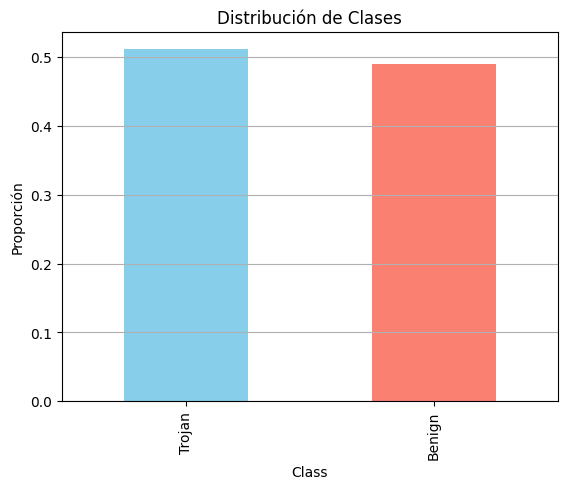

In [4]:

df['Class'].value_counts()
df['Class'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Clases')
plt.ylabel('Proporción')
plt.grid(axis='y')
plt.show()


**Figura 1.** Distribución de clases en el dataset. Se observa que el conjunto de datos está aproximadamente balanceado entre tráfico clasificado como `Trojan` (troyano) y `Benign` (normal), con proporciones cercanas al 51% y 49% respectivamente. Esta característica es favorable para el entrenamiento de modelos de clasificación supervisada, ya que evita sesgos hacia una sola clase y facilita la optimización de métricas como precisión, recall y F1-score.

In [5]:
# Calcular varianza por columna
num_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Unnamed: 0'], errors='ignore')
variances = num_cols.var().sort_values(ascending=False)

# Mostrar top 10 columnas más variables
top_vars = variances.head(10).index
df[top_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,177482.0,1.163310e+07,2.302798e+07,2.0,46900.5,485402.500000,10620349.50,119999100.0
Fwd IAT Total,177482.0,8.119008e+06,1.989469e+07,0.0,0.0,198266.000000,3850230.00,119999030.0
Flow IAT Max,177482.0,1.011208e+07,1.955816e+07,2.0,37076.0,273186.500000,10041571.00,119773643.0
Bwd IAT Total,177482.0,6.320937e+06,1.914869e+07,0.0,0.0,0.000000,264852.25,119996974.0
Idle Max,177482.0,4.894188e+06,1.627581e+07,0.0,0.0,0.000000,0.00,119773643.0
Bwd IAT Max,177482.0,5.343716e+06,1.617506e+07,0.0,0.0,0.000000,149502.75,119810606.0
Fwd IAT Max,177482.0,6.786882e+06,1.601300e+07,0.0,0.0,88484.000000,2993243.00,119851636.0
Idle Mean,177482.0,4.540725e+06,1.542957e+07,0.0,0.0,0.000000,0.00,119773643.0
Idle Min,177482.0,4.234695e+06,1.504980e+07,0.0,0.0,0.000000,0.00,119773643.0
Fwd IAT Mean,177482.0,3.149868e+06,8.704633e+06,0.0,0.0,35583.404762,1146195.50,118678332.0


Dado que el dataset original cuenta con más de 80 columnas numéricas, muchas de las cuales presentan valores constantes o baja variación, se aplicó un filtro por **varianza mínima**. Esta técnica elimina aquellas columnas que no aportan información significativa para la clasificación.

En esta etapa, se utilizó `VarianceThreshold` con un umbral de `0.01`, lo que redujo la dimensionalidad de **81 a 68 columnas numéricas útiles**.

Para entender mejor el comportamiento de las variables más informativas, se analizaron las **10 columnas con mayor varianza**. Estas variables reflejan una mayor dispersión de valores en el conjunto de datos, lo que las convierte en candidatas fuertes para modelar patrones relacionados con el comportamiento anómalo o malicioso de una conexión de red.

Columnas más variables

- `Flow Duration`, `Fwd IAT Total`, `Flow IAT Max`, `Bwd IAT Total`, `Idle Max`, entre otras.
- Estas columnas tienen valores máximos cercanos a **120 millones**, mientras que sus medianas (`50%`) son cercanas a **0**, lo que evidencia una distribución **extremadamente asimétrica**.
- Tal comportamiento sugiere que la mayoría de los registros tienen tráfico mínimo, pero algunos casos presentan flujos muy prolongados o picos de actividad, lo cual es típico en sesiones de malware como los troyanos.

Este análisis justifica la importancia de estas columnas en tareas de clasificación y motiva su uso en la construcción del grafo para el modelo GCN.

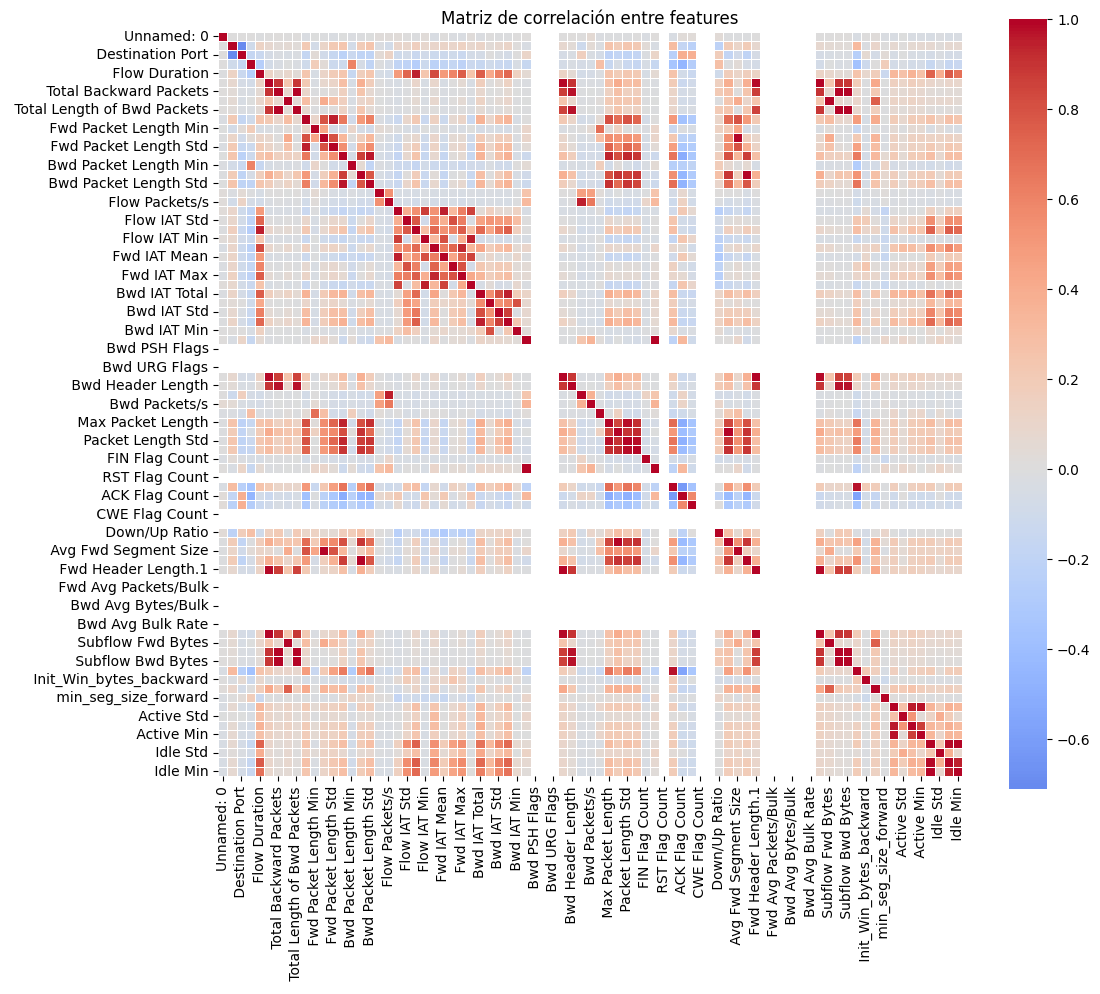

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title("Matriz de correlación entre features")
plt.show()

La figura muestra la **matriz de correlación** entre las características numéricas del dataset, visualizada mediante un mapa de calor. Cada celda representa el coeficiente de correlación de Pearson entre dos variables, donde:

- Existen grupos de variables **fuertemente correlacionadas**, como por ejemplo:
  - `Flow IAT Max`, `Fwd IAT Total`, `Bwd IAT Total`
  - `Packet Length Mean`, `Avg Fwd Segment Size`, `Avg Bwd Segment Size`
  - `Total Length of Fwd Packets` y `Fwd Packet Length Mean/Std`

- Algunas variables como `Flow Duration`, `Idle Mean`, y `Active Mean` muestran correlaciones importantes con múltiples atributos.

- La presencia de **correlaciones altas** entre múltiples variables sugiere la posibilidad de **redundancia**.
- Esto no es necesariamente un problema para modelos complejos como GCN (que pueden aprender relaciones no lineales), pero sí puede afectar otros algoritmos si no se controla.
- De cara al modelado, se puede considerar:
  - Eliminar o fusionar variables altamente correlacionadas.
  - Aplicar reducción de dimensionalidad (PCA, UMAP) si se desea compactar el espacio.


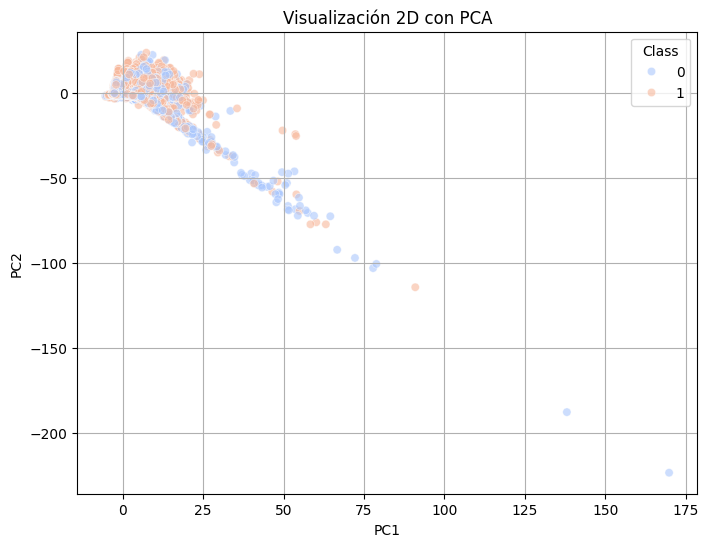

In [7]:
from sklearn.decomposition import PCA

X = df.select_dtypes(include='number').drop(columns=['Unnamed: 0'], errors='ignore')
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
y = df['Class'].map({'Benign': 0, 'Trojan': 1})

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', alpha=0.6)
plt.title("Visualización 2D con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

Para explorar la estructura del dataset y la posible separabilidad de clases, se aplicó un **Análisis de Componentes Principales (PCA)** sobre las variables seleccionadas. Esta técnica proyecta los datos en un nuevo espacio 2D que maximiza la varianza explicada con las primeras dos componentes principales.

**Figura 2.** Visualización en 2 dimensiones de las muestras utilizando PCA. Las clases `Benign` (0) y `Trojan` (1) se representan en colores diferentes.

- Existe una **superposición considerable** entre las clases, especialmente en la zona densa superior izquierda del gráfico.
- Algunas muestras `Trojan` se alejan del núcleo, indicando casos que podrían representar comportamientos más anómalos.
- Aunque no hay una separación lineal clara, se observa que los puntos siguen una cierta estructura que podría ser explotada por un modelo no lineal como un GCN.


La proyección en PCA revela que las clases no son separables fácilmente por métodos lineales simples, lo que refuerza la decisión de emplear modelos más complejos como las **Redes Convolucionales sobre Grafos (GCN)**, capaces de capturar relaciones estructurales entre muestras a partir de sus similitudes.

## Método


Este trabajo implementa un modelo de detección de troyanos utilizando **Redes Convolucionales sobre Grafos (GCN)**, tal como se propone en el artículo original. El enfoque consta de dos pasos principales:

1. **Conversión del dataset en un grafo**
2. **Definición y entrenamiento del modelo GCN**

In [8]:
print(torch.__version__)
print(torch.version.cuda)
print(torch_geometric.__version__)
print(torch.cuda.is_available())

2.7.1+cu128
12.8
2.6.1
True


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
## Preprocesamiento de Datos

# Mapear etiquetas: Benign=0, Trojan=1
y = df['Class'].map({'Benign': 0, 'Trojan': 1}).values

# Seleccionar solo features numéricos
num_df = df.select_dtypes(include=[np.number]).copy()
# Eliminar columna de índice si existe
if 'Unnamed: 0' in num_df.columns:
    num_df = num_df.drop(columns=['Unnamed: 0'])
X = num_df.values

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en training/validation
tX, vX, ty, vy = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

### Representación en forma de grafo

Dado que los GCN están diseñados para procesar datos estructurados como grafos, es necesario transformar el conjunto de datos tabular en una estructura de grafo. Para esto:

- Cada **nodo** representa una instancia (fila) del dataset.
- Las **aristas** se definen usando un algoritmo de **vecinos más cercanos (K-Nearest Neighbors)** aplicado sobre los vectores de características.
- La matriz de adyacencia del grafo se construye conectando cada nodo con sus `k` vecinos más cercanos según una métrica de distancia (por defecto, Euclidean).
- El resultado es un grafo no dirigido con aristas **bidireccionales** (simétricas).

Esta estructura permite capturar similitudes entre instancias en términos de sus características, lo que es útil para identificar patrones locales entre conexiones benignas y maliciosas.

In [12]:
## 4. Construcción del Grafo con KNN

k = 8  # número de vecinos
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(tX)
distances, indices = nbrs.kneighbors(tX)

# Generar edge_index bidireccional
src, dst = [], []
for i, neigh in enumerate(indices):
    for j in neigh[1:]:  # omitir self-loop
        src.extend([i, j])
        dst.extend([j, i])
edge_index = torch.tensor([src, dst], dtype=torch.long)

# Crear objeto PyG Data para entrenamiento
data = Data(
    x=torch.tensor(tX, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(ty, dtype=torch.long)
)
loader = DataLoader([data], batch_size=1)

In [13]:
# Construcción del grafo para validación con KNN
nbrs_val = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(vX)
distances_val, indices_val = nbrs_val.kneighbors(vX)

src_val, dst_val = [], []
for i, neigh in enumerate(indices_val):
    for j in neigh[1:]:  # omitir self-loop
        src_val.extend([i, j])
        dst_val.extend([j, i])
edge_index_val = torch.tensor([src_val, dst_val], dtype=torch.long)

# Crear objeto Data para validación
val_data = Data(
    x=torch.tensor(vX, dtype=torch.float),
    edge_index=edge_index_val,
    y=torch.tensor(vy, dtype=torch.long)
)

#### Definición de nodos y aristas

- Cada **instancia** del dataset (`tX`) es considerada como un **nodo** del grafo.
- Se utiliza el algoritmo de **vecinos más cercanos (K-Nearest Neighbors, KNN)** para determinar las conexiones (aristas) entre nodos:
  - Para cada nodo, se seleccionan sus `k = 8` vecinos más cercanos en el espacio de características normalizado.
  - La métrica de distancia usada por defecto es la **euclídea**, y el algoritmo KNN se optimiza usando `ball_tree`.

#### Construcción de `edge_index`

- Se genera un grafo **no dirigido**, es decir, si el nodo `i` está conectado con el nodo `j`, también se crea la arista inversa (`j` ↔ `i`).
- Esto se traduce en un **índice de aristas bidireccional**, representado como un tensor de forma `(2, num_edges)` en PyTorch Geometric (`edge_index`), donde cada columna es un par de nodos conectados.

#### Estructura final del grafo

El grafo se encapsula en un objeto `Data` de PyTorch Geometric, que incluye:
- `x`: la matriz de características de los nodos (tX).
- `edge_index`: las aristas entre nodos construidas por KNN.
- `y`: las etiquetas de clase (`Trojan` o `Benign`) como objetivo de entrenamiento.

Este objeto es luego cargado en un `DataLoader` con batch size 1, ya que se trata de un solo grafo que representa todo el conjunto de entrenamiento. Esta estructura es la entrada esperada por el modelo GCN.

### Modelo GCN

El modelo empleado está basado en la arquitectura de **Graph Convolutional Network (GCN)** con las siguientes características, según lo reportado en el artículo:

- Dos capas `GCNConv` con **32 unidades ocultas** cada una.
- Función de activación **ReLU**.
- Regularización con **Dropout = 0.5** entre capas.
- Una capa densa final `Linear(32 → 1)` que devuelve un único logit por nodo.
- Función de pérdida: **`BCEWithLogitsLoss`** (clasificación binaria).
- Optimización: **Adam** con `lr = 0.01`, `weight_decay = 5e-4`.

Este diseño busca capturar patrones de conectividad y estructura local en el grafo, y aprender representaciones discriminativas de cada nodo para predecir su clase (`Trojan` o `Benign`).

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.out = nn.Linear(hidden_channels, 1)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        return self.out(x)


In [15]:
# Instanciar modelo (en CPU para evitar errores CUDA)
model_gcn = GCN(
    in_channels=tX.shape[1],
    hidden_channels=32,
    dropout=0.5
).to(device)

model_gcn

GCN(
  (conv1): GCNConv(80, 32)
  (conv2): GCNConv(32, 32)
  (out): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [16]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

In [17]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train = data.x.to(device)
edge_index_train = data.edge_index.to(device)

epochs = 500
for epoch in range(epochs):
    model_gcn.train()

    y_logits = model_gcn(X_train, edge_index_train)

    loss = loss_fn(y_logits, data.y.to(device).float().view(-1, 1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_gcn.eval()
    with torch.no_grad():
        X_val = val_data.x.to(device)
        edge_index_val = val_data.edge_index.to(device)

        y_logits_val = model_gcn(X_val, edge_index_val)
        y_pred_val = torch.round(torch.sigmoid(y_logits_val))

        val_loss = loss_fn(y_logits_val, val_data.y.to(device).float().view(-1, 1))
        val_acc = (y_pred_val == val_data.y.to(device)).float().mean()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 000, Loss: 0.7374, Val Loss: 0.6944, Val Acc: 0.4957
Epoch 050, Loss: 0.6647, Val Loss: 0.6623, Val Acc: 0.4996
Epoch 100, Loss: 0.6494, Val Loss: 0.6456, Val Acc: 0.4989
Epoch 150, Loss: 0.6438, Val Loss: 0.6413, Val Acc: 0.4978
Epoch 200, Loss: 0.6419, Val Loss: 0.6418, Val Acc: 0.4970
Epoch 250, Loss: 0.6376, Val Loss: 0.6363, Val Acc: 0.4981
Epoch 300, Loss: 0.6379, Val Loss: 0.6366, Val Acc: 0.4983
Epoch 350, Loss: 0.6340, Val Loss: 0.6339, Val Acc: 0.4983
Epoch 400, Loss: 0.6339, Val Loss: 0.6329, Val Acc: 0.4987
Epoch 450, Loss: 0.6333, Val Loss: 0.6328, Val Acc: 0.4990


## Mejorando el Modelo

In [24]:
def submuestrear_dataset(df, frac=0.1):
    # Submuestrea manteniendo proporción de clases
    df_sampled = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))
    print(f"Dataset original: {df.shape[0]} filas → Submuestreo: {df_sampled.shape[0]} filas")
    return df_sampled.reset_index(drop=True)

In [35]:
df_sampled = submuestrear_dataset(df, frac=0.25)

y = df_sampled['Class'].map({'Benign': 0, 'Trojan': 1}).values

# Seleccionar solo features numéricos
num_df = df_sampled.select_dtypes(include=[np.number]).copy()
# Eliminar columna de índice si existe
if 'Unnamed: 0' in num_df.columns:
    num_df = num_df.drop(columns=['Unnamed: 0'])
X = num_df.values

# Normalizar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en training/validation
tX, vX, ty, vy = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

Dataset original: 177482 filas → Submuestreo: 44371 filas


C:\Users\nalvarez\AppData\Local\Temp\ipykernel_15648\1491430021.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby("Class", group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))


In [36]:
k = 32  # número de vecinos
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(tX)
distances, indices = nbrs.kneighbors(tX)

# Generar edge_index bidireccional
src, dst = [], []
for i, neigh in enumerate(indices):
    for j in neigh[1:]:  # omitir self-loop
        src.extend([i, j])
        dst.extend([j, i])
edge_index = torch.tensor([src, dst], dtype=torch.long)

# Crear objeto PyG Data para entrenamiento
data = Data(
    x=torch.tensor(tX, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(ty, dtype=torch.long)
)
loader = DataLoader([data], batch_size=1)


# Construcción del grafo para validación con KNN
nbrs_val = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(vX)
distances_val, indices_val = nbrs_val.kneighbors(vX)

src_val, dst_val = [], []
for i, neigh in enumerate(indices_val):
    for j in neigh[1:]:  # omitir self-loop
        src_val.extend([i, j])
        dst_val.extend([j, i])
edge_index_val = torch.tensor([src_val, dst_val], dtype=torch.long)

# Crear objeto Data para validación
val_data = Data(
    x=torch.tensor(vX, dtype=torch.float),
    edge_index=edge_index_val,
    y=torch.tensor(vy, dtype=torch.long)
)

In [37]:
model_gcn = GCN(
    in_channels=tX.shape[1],
    hidden_channels=32,
    dropout=0.5
).to(device)

model_gcn

GCN(
  (conv1): GCNConv(80, 32)
  (conv2): GCNConv(32, 32)
  (out): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [38]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train = data.x.to(device)
edge_index_train = data.edge_index.to(device)

epochs = 500
for epoch in range(epochs):
    model_gcn.train()

    y_logits = model_gcn(X_train, edge_index_train)

    loss = loss_fn(y_logits, data.y.to(device).float().view(-1, 1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_gcn.eval()
    with torch.no_grad():
        X_val = val_data.x.to(device)
        edge_index_val = val_data.edge_index.to(device)

        y_logits_val = model_gcn(X_val, edge_index_val)
        y_pred_val = torch.round(torch.sigmoid(y_logits_val))

        val_loss = loss_fn(y_logits_val, val_data.y.to(device).float().view(-1, 1))
        val_acc = (y_pred_val == val_data.y.to(device)).float().mean()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 000, Loss: 0.7082, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 050, Loss: 0.7071, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 100, Loss: 0.7061, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 150, Loss: 0.7079, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 200, Loss: 0.7083, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 250, Loss: 0.7080, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 300, Loss: 0.7073, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 350, Loss: 0.7074, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 400, Loss: 0.7069, Val Loss: 0.7006, Val Acc: 0.4900
Epoch 450, Loss: 0.7076, Val Loss: 0.7006, Val Acc: 0.4900


In [39]:
from sklearn.metrics import classification_report

# Convertimos a NumPy para usar sklearn
y_true = val_data.y.cpu().numpy()
y_pred = y_pred_val.cpu().numpy().flatten()

# Imprimir métricas detalladas
print(classification_report(y_true, y_pred, target_names=["Benign", "Trojan"]))

              precision    recall  f1-score   support

      Benign       0.49      0.96      0.65      4340
      Trojan       0.57      0.05      0.09      4535

    accuracy                           0.50      8875
   macro avg       0.53      0.51      0.37      8875
weighted avg       0.53      0.50      0.37      8875



### Implementación de un modelo LSTM

In [37]:
num_df = df.select_dtypes(include=[np.number]).copy()
if 'Unnamed: 0' in num_df.columns:
    num_df = num_df.drop(columns=['Unnamed: 0'])

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df.values)

In [39]:
import numpy as np

X_seq = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_seq, y, test_size=0.2, stratify=y, random_state=42)

In [41]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                              torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                            torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])  # último hidden state
        return out


In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [44]:
input_dim = 1  # porque tratamos cada característica como paso en la secuencia
model = LSTMClassifier(input_dim=input_dim).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [45]:
from sklearn.metrics import classification_report

num_epochs = 1000

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Forward
        logits = model(xb)
        loss = loss_fn(logits, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validación
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            preds = torch.round(torch.sigmoid(logits))
            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    # Concatenar
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:02d} | Loss: {total_loss:.4f}")
        print(classification_report(all_labels, all_preds, target_names=["Benign", "Trojan"], zero_division=0))


Epoch 00 | Loss: 1533.6053
              precision    recall  f1-score   support

      Benign       0.50      0.91      0.64     17360
      Trojan       0.60      0.13      0.21     18137

    accuracy                           0.51     35497
   macro avg       0.55      0.52      0.43     35497
weighted avg       0.55      0.51      0.42     35497

Epoch 100 | Loss: 1534.5693
              precision    recall  f1-score   support

      Benign       0.51      0.22      0.31     17360
      Trojan       0.52      0.80      0.63     18137

    accuracy                           0.51     35497
   macro avg       0.51      0.51      0.47     35497
weighted avg       0.51      0.51      0.47     35497

